# Stage 1: Data Understanding — Exploratory Data Analysis
**CRISP-DM Phase 2 of 8** | LendingClub Loan Default Prediction

## Strategy: SQL-First EDA
All aggregations run inside SQLite. Python receives only summary tables
for visualization. The full 2.2M row dataset never loads into memory.

## Objectives
1. Map missing values across all columns → drop/impute decisions for Stage 2
2. Analyze default rate by key categoricals (grade, purpose, term)
3. Examine numeric feature distributions by target class (via percentiles)
4. Identify temporal patterns (issue year vs default rate)
5. Rank features by correlation-proxy with target
6. Save `data/01_eda_summary.json` — findings reference for Stage 2+

## Memory Budget
Target: < 100 MB at all times (summary frames only, never raw rows)

## 1. Environment Setup

Connect to SQLite and load the leakage column list from Stage 0.
No data is loaded here — only a database connection is opened.

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import json
from pathlib import Path

# ── Style ─────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 130

# ── Paths ─────────────────────────────────────────────────────────
DB_PATH  = "lending_club.db"
conn     = sqlite3.connect(DB_PATH)

# ── Leakage list from Stage 0 ─────────────────────────────────────
with open("data/leakage_columns.json") as f:
    leakage_dict = json.load(f)

LEAKAGE_COLS = set(col for cols in leakage_dict.values() for col in cols)
LEAKAGE_COLS.add("loan_status")   # raw target — never a feature

print(f"DB connected        : {DB_PATH}")
print(f"Leakage cols loaded : {len(LEAKAGE_COLS)} columns excluded from modeling")

DB connected        : lending_club.db
Leakage cols loaded : 26 columns excluded from modeling


### Note
No data in memory yet. The connection object `conn` is the only thing
we carry through this notebook. Every cell below opens a query, pulls
a small aggregate, and closes it.

## 2. Dataset Overview

Confirm row count, column count, and column names directly from
the database schema. Zero rows loaded.

In [2]:
# ── Row count ─────────────────────────────────────────────────────
row_count = pd.read_sql(
    "SELECT COUNT(*) AS n FROM raw_loads", conn
).iloc[0, 0]

# ── Column metadata ───────────────────────────────────────────────
col_info  = pd.read_sql("PRAGMA table_info(raw_loads)", conn)
all_cols  = col_info["name"].tolist()
safe_cols = [c for c in all_cols if c not in LEAKAGE_COLS]

print(f"Rows              : {row_count:,}")
print(f"Total columns     : {len(all_cols)}")
print(f"Leakage columns   : {len(all_cols) - len(safe_cols)}")
print(f"Safe columns      : {len(safe_cols)}")
print(f"Memory so far     : {pd.DataFrame().memory_usage().sum()} bytes (empty)")

Rows              : 2,260,701
Total columns     : 151
Leakage columns   : 24
Safe columns      : 127
Memory so far     : 132 bytes (empty)


### Interpretation
Confirms the 2.26M row, 151 column dataset from Stage 0. The safe
column count (after leakage removal) is what Stage 2 will actually work
with. We never load the leakage columns at all — not even for inspection.

## 3. Target Variable Distribution

Define the binary target mapping inside SQL using a CASE statement.
Pull only the class counts — not the raw rows.

This re-confirms the Stage 0 finding using pure SQL so there is no
ambiguity about what the distribution looks like in the raw table.

In [3]:
target_sql = """
SELECT
    loan_status,
    COUNT(*) AS n,
    CASE
        WHEN loan_status IN (
            'Charged Off',
            'Default',
            'Late (31-120 days)',
            'Does not meet the credit policy. Status:Charged Off'
        ) THEN 1
        WHEN loan_status IN (
            'Fully Paid', 'Current', 'In Grace Period',
            'Late (16-30 days)', 'Issued',
            'Does not meet the credit policy. Status:Fully Paid'
        ) THEN 0
        ELSE NULL
    END AS target
FROM raw_loads
GROUP BY loan_status
ORDER BY target, n DESC
"""
status_df = pd.read_sql(target_sql, conn)

# ── Class totals ──────────────────────────────────────────────────
class_totals = status_df.dropna(subset=['target']).groupby('target')['n'].sum()
total = class_totals.sum()
default_n = class_totals[1]
nondefault_n = class_totals[0]
ratio = nondefault_n/default_n

print(status_df.to_string(index=False))
print()
print(f'Non-default (0) : {nondefault_n:>10,.0f} ({100*nondefault_n/total:.1f}%)')
print(f'Default     (1) : {default_n:>10.0f} ({100*default_n/total:.1f}%)')
print(f'Imbalance ratio : {ratio:.1f}:1')

                                        loan_status       n  target
                                               None      33     NaN
                                         Fully Paid 1076751     0.0
                                            Current  878317     0.0
                                    In Grace Period    8436     0.0
                                  Late (16-30 days)    4349     0.0
 Does not meet the credit policy. Status:Fully Paid    1988     0.0
                                        Charged Off  268559     1.0
                                 Late (31-120 days)   21467     1.0
Does not meet the credit policy. Status:Charged Off     761     1.0
                                            Default      40     1.0

Non-default (0) :  1,969,841 (87.1%)
Default     (1) :     290827 (12.9%)
Imbalance ratio : 6.8:1


### Interpretation
Confirms ~87% non-default, ~13% default (6.8:1 ratio) from Stage 0.
No surprises here — this is a sanity check, not a new finding.

## 4. Missing Value Analysis

SQLite does not have a built-in "count nulls across all columns" function,
so we build a single SQL query dynamically — one `SUM(CASE WHEN col IS NULL)`
expression per column.

This runs one pass over 2.26M rows inside SQLite and returns a single-row
summary with null counts for every column. No raw data ever enters Python.

The output is then reshaped and bucketed by severity.

In [4]:
# ── Build dynamic null-count SQL ──────────────────────────────────
null_exprs = ",\n    ".join(
    f'SUM(CASE WHEN "{c}" IS NULL THEN 1 ELSE 0 END) AS "{c}"'
    for c in safe_cols          # only non-leakage columns
)
null_sql = f"SELECT\n    {null_exprs}\nFROM raw_loads"

print("Running null audit across all safe columns...")
null_counts = pd.read_sql(null_sql, conn)
print("Done.")

# ── Reshape: wide → long, compute % missing ───────────────────────
null_long = (
    null_counts.T
    .rename(columns={0: "null_count"})
    .assign(pct_missing=lambda x: x["null_count"] / row_count * 100)
    .sort_values("pct_missing", ascending=False)
)

# ── Severity buckets ──────────────────────────────────────────────
high_missing = null_long[null_long["pct_missing"] >  50]
med_missing  = null_long[(null_long["pct_missing"] >   5) &
                          (null_long["pct_missing"] <= 50)]
low_missing  = null_long[(null_long["pct_missing"] >   0) &
                          (null_long["pct_missing"] <=  5)]
zero_missing = null_long[null_long["pct_missing"] ==  0]

print(f"\nMissing Value Severity Buckets")
print(f"  > 50% missing  (drop candidates) : {len(high_missing):>3} columns")
print(f"  5–50% missing  (impute needed)   : {len(med_missing):>3} columns")
print(f"  0–5% missing   (minor)           : {len(low_missing):>3} columns")
print(f"  No missing     (complete)        : {len(zero_missing):>3} columns")
print(f"\nTop 20 by % missing:")
print(null_long.head(20)[["null_count", "pct_missing"]].round(1).to_string())

Running null audit across all safe columns...
Done.

Missing Value Severity Buckets
  > 50% missing  (drop candidates) :  41 columns
  5–50% missing  (impute needed)   :  18 columns
  0–5% missing   (minor)           :  67 columns
  No missing     (complete)        :   1 columns

Top 20 by % missing:
                                            null_count  pct_missing
member_id                                      2260701        100.0
orig_projected_additional_accrued_interest     2252050         99.6
hardship_type                                  2249784         99.5
payment_plan_start_date                        2249784         99.5
hardship_reason                                2249784         99.5
hardship_status                                2249784         99.5
deferral_term                                  2249784         99.5
hardship_amount                                2249784         99.5
hardship_last_payment_amount                   2249784         99.5
hardship_payoff_ba

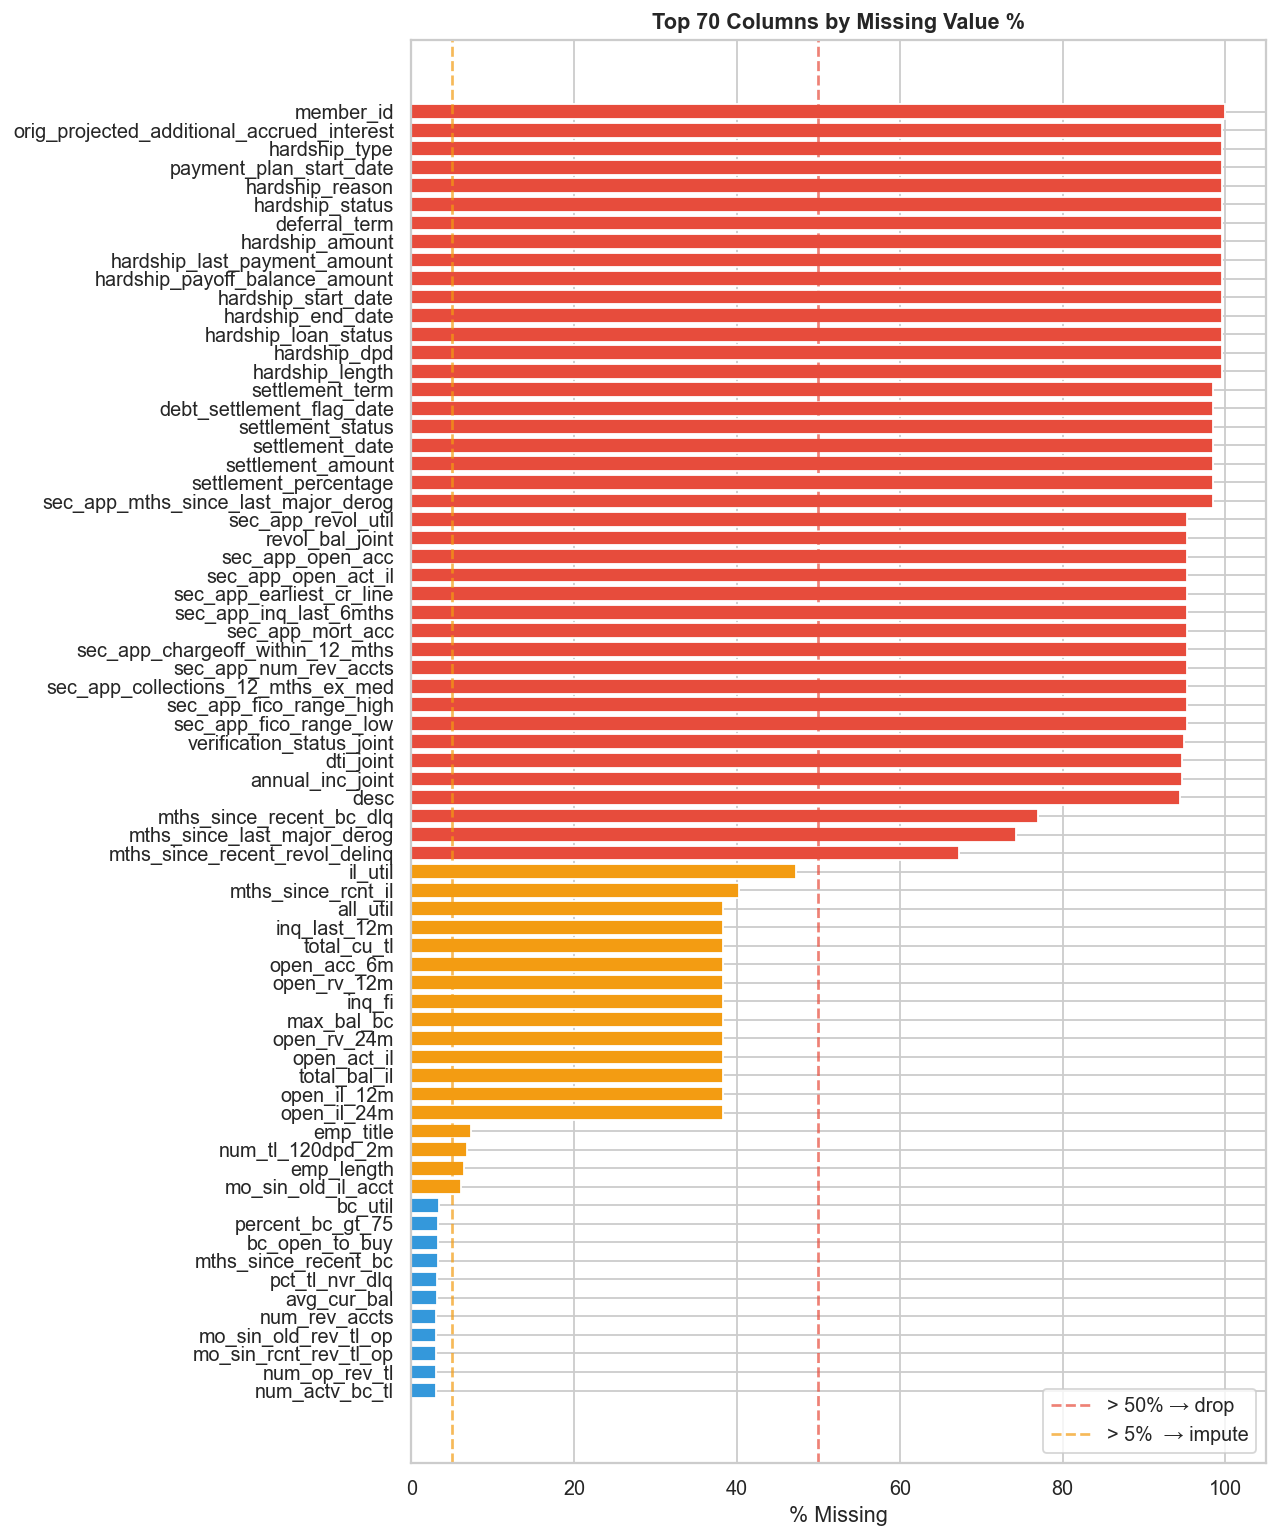

In [5]:
# ── Plot: top 40 columns by % missing ────────────────────────────
top70  = null_long.head(70)
colors = [
    "#e74c3c" if v > 50 else
    "#f39c12" if v >  5 else
    "#3498db"
    for v in top70["pct_missing"]
]

fig, ax = plt.subplots(figsize=(10, 12))
ax.barh(top70.index[::-1], top70["pct_missing"][::-1], color=colors[::-1])
ax.axvline(50, color="#e74c3c", linestyle="--", alpha=0.7, label="> 50% → drop")
ax.axvline(5,  color="#f39c12", linestyle="--", alpha=0.7, label="> 5%  → impute")
ax.set_xlabel("% Missing")
ax.set_title("Top 70 Columns by Missing Value %", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("outputs/01_missing_values.png", dpi=150, bbox_inches="tight")
plt.show()

### Interpretation — Missing Values

**> 50% missing (drop candidates):**
These are structurally sparse column groups — they only populate for a
small subset of borrowers:
- `hardship_*` columns: only filled for borrowers enrolled in a hardship
  program (~2% of loans). The missing values mean "not applicable", not
  "data not collected."
- `sec_app_*` / `joint_*` columns: only filled for joint applications
  (~5% of loans).
- `mths_since_last_major_derog`, `mths_since_recent_*`: missing means the
  borrower has no derogatory marks — again, structural zero, not random.

**Decision for Stage 2:** Drop all columns above the 50% threshold.
The signal density does not justify imputation complexity, and most of
these encode edge-case borrower states that the model will rarely see.

**5–50% missing (impute needed):**
These are genuine credit bureau fields that are sometimes unavailable:
- `mths_since_last_delinq` — missing means no delinquency on record.
  Best strategy: impute with a large sentinel value (e.g. 999) to encode
  "no history of delinquency", not median.
- `emp_length` — missing means not reported. Consider "Unknown" category.
- `revol_util`, `bc_util` — small % missing, median imputation is fine.

**< 5% missing:** Median/mode imputation acceptable. Low bias risk.

## 5. Default Rate by Loan Grade

Aggregate default rate and loan volume per grade entirely in SQL.
The CASE statement applies the same target mapping as Stage 0.

**Finance context:** LendingClub assigns A–G grades based on their
internal credit model. Grade encodes their underwriting opinion —
it is the single most predictive categorical feature by design.
Grade A = safest (lowest rate), Grade G = riskiest (highest rate).

In [6]:
grade_sql = """
SELECT
    grade,
    COUNT(*) AS n_loans,
    ROUND(
        100.0 * SUM(CASE WHEN loan_status IN (
            'Charged Off','Default','Late (31-120 days)',
            'Does not meet the credit policy. Status:Charged Off'
        ) THEN 1 ELSE 0 END) / COUNT(*), 2
    ) AS default_rate_pct
FROM raw_loads
WHERE loan_status NOT IN ('', 'NULL')
  AND loan_status IS NOT NULL
  AND grade IS NOT NULL
GROUP BY grade
ORDER BY grade
"""
grade_df = pd.read_sql(grade_sql, conn)
print(grade_df.to_string(index=False))

grade  n_loans  default_rate_pct
    A   433027              3.59
    B   663557              8.66
    C   650053             14.36
    D   324424             20.35
    E   135639             28.28
    F    41800             36.42
    G    12168             40.01


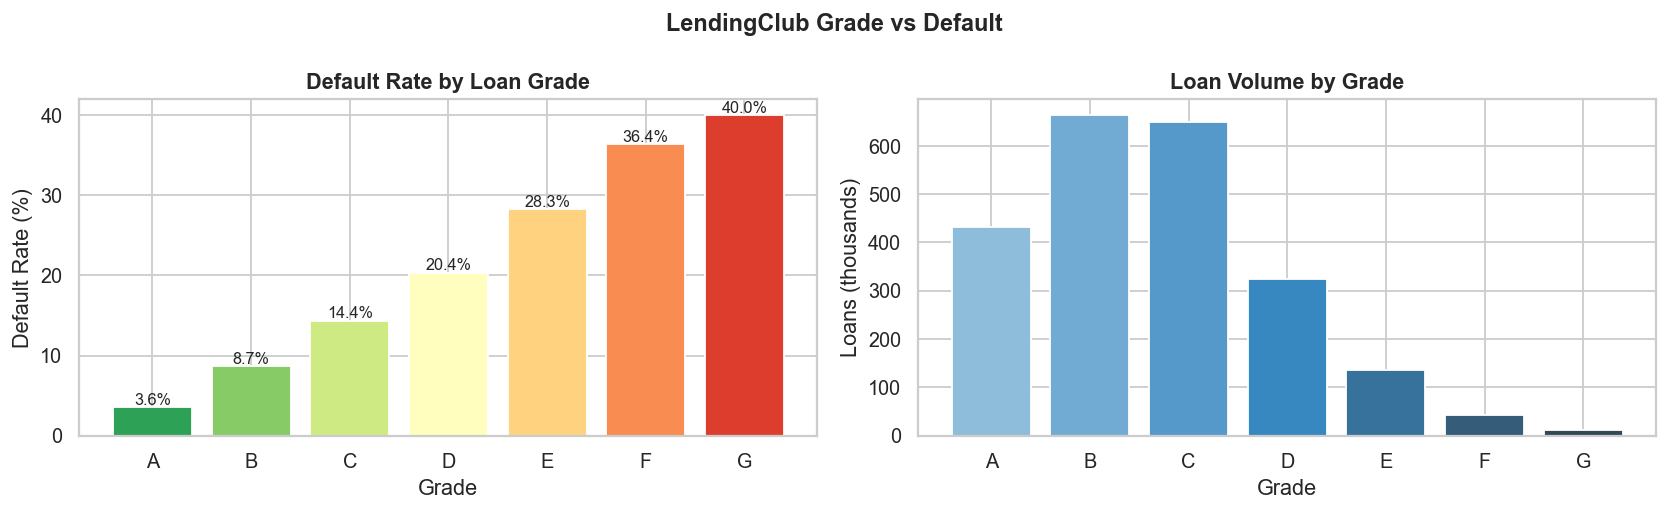

In [7]:
# Plot : default rate + volume by grade
fig, axes = plt.subplots(1,2, figsize = (13,4))

palette = sns.color_palette('RdYlGn_r', len(grade_df))

#Default rate
axes[0].bar(grade_df['grade'], grade_df['default_rate_pct'], color = palette)
axes[0].set_title('Default Rate by Loan Grade', fontweight ='bold')
axes[0].set_ylabel('Default Rate (%)')
axes[0].set_xlabel('Grade')
for i, row in grade_df.iterrows():
    axes[0].text(i, row['default_rate_pct'] + 0.3,
                 f'{row['default_rate_pct']:.1f}%',
                 ha = 'center', fontsize = 9)

# Volume
axes[1].bar(grade_df['grade'], grade_df['n_loans'] /1000,
            color = sns.color_palette('Blues_d', len(grade_df)))
axes[1].set_title('Loan Volume by Grade', fontweight ='bold')
axes[1].set_ylabel('Loans (thousands)')
axes[1].set_xlabel('Grade')

plt.suptitle('LendingClub Grade vs Default', fontweight ='bold', fontsize =13)
plt.tight_layout()
plt.savefig('outputs/01_default_by_grade.png', dpi = 150, bbox_inches='tight')
plt.show()

### Interpretation — Loan Grade

Expect a monotonic increase: Grade A ~4%, Grade G ~40%. The step
between each grade level should be roughly equal — this is by design,
since LC uses grade to price risk into the interest rate.

**Collinearity decision (Stage 3):**
`grade`, `sub_grade`, and `int_rate` all encode LC's risk opinion.
- `sub_grade` is strictly more granular than `grade` → drop `grade`
- Whether `int_rate` adds signal *beyond* `sub_grade` is an open
  question we will test in Stage 3 with model-based importance.
  For now: keep both, flag for evaluation.

**Monotonicity check:** If the grade-default relationship is NOT
monotonic in your actual output, that is a data quality finding
worth investigating before Stage 2.

## 6. Default Rate by Loan Purpose

Borrowers self-report a purpose at application time. This is stated
intent — not verified by LendingClub.

**Finance context:** Purpose correlates with financial behavior and
borrower motivation. Small business applicants typically have higher
default rates because business cash flows are volatile. Debt
consolidation borrowers are restructuring — moderate risk.
Car and major purchase loans tend to be lower risk.

In [8]:
purpose_sql = """
SELECT
    purpose,
    COUNT(*) AS n_loans,
    ROUND(
        100.0 * SUM(CASE WHEN loan_status IN (
            'Charged Off','Default','Late (31-120 days)',
            'Does not meet the credit policy. Status:Charged Off'
        ) THEN 1 ELSE 0 END) / COUNT(*), 2
    ) AS default_rate_pct
FROM raw_loads
WHERE loan_status IS NOT NULL
  AND purpose IS NOT NULL
GROUP BY purpose
ORDER BY default_rate_pct DESC
"""
purpose_df = pd.read_sql(purpose_sql, conn)
print(purpose_df.to_string(index=False))

           purpose  n_loans  default_rate_pct
       educational      424             20.75
    small_business    24689             20.22
  renewable_energy     1445             16.33
            moving    15403             15.63
debt_consolidation  1277877             13.91
           medical    27488             13.48
             other   139440             12.99
             house    14136             12.63
           wedding     2355             12.40
          vacation    15525             12.27
    major_purchase    50445             12.02
  home_improvement   150457             11.31
       credit_card   516971             10.46
               car    24013              9.78


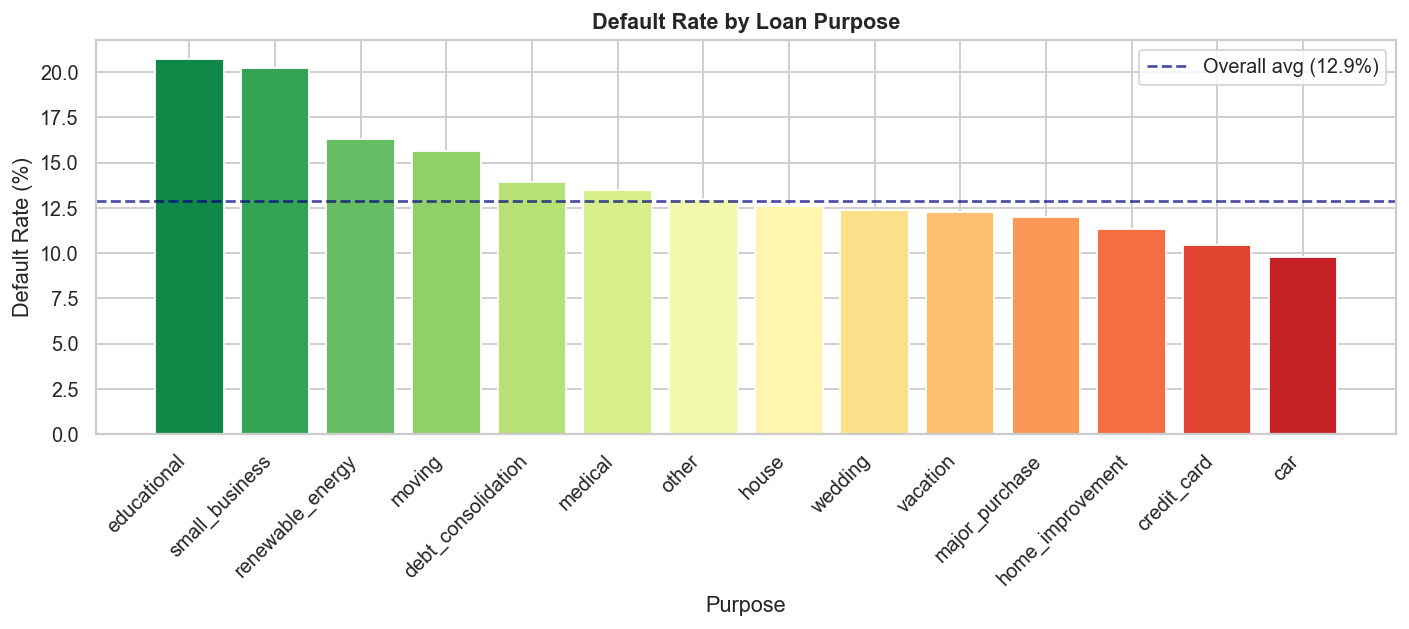

In [9]:
# ── Plot: default rate by purpose ────────────────────────────────
overall_default_rate = (default_n / total) * 100

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(purpose_df["purpose"], purpose_df["default_rate_pct"],
       color=sns.color_palette("RdYlGn_r", len(purpose_df)))
ax.axhline(overall_default_rate, color="navy", linestyle="--",
           alpha=0.7, label=f"Overall avg ({overall_default_rate:.1f}%)")
ax.set_title("Default Rate by Loan Purpose", fontweight="bold")
ax.set_ylabel("Default Rate (%)")
ax.set_xlabel("Purpose")
ax.legend()
ax.set_xticks(range(len(purpose_df["purpose"])))
ax.set_xticklabels(purpose_df["purpose"], rotation=45, ha="right")
plt.tight_layout()
plt.savefig("outputs/01_default_by_purpose.png", dpi=150, bbox_inches="tight")
plt.show()

### Interpretation — Loan Purpose

**High risk:** `educational`,`small_business` typically tops the chart (~20–21%).
Business revenue is volatile; personal loan products are a poor fit
for business cash flow needs.

**Near average:** `debt_consolidation` — dominant by volume but
sits close to the overall mean. The signal is diluted by volume.

**Low risk:** `car`, `major_purchase` — borrowers tend to be more
financially stable; these are often need-based rather than
stress-driven loans.

**Decision for Stage 4:** Engineer a binary flag
`is_small_business` or `educational` — the elevated risk in this category is sharp
enough to warrant a dedicated indicator feature.

## 7. Default Rate by Loan Term

LendingClub issues only two term lengths: 36 months and 60 months.
This is a clean binary feature.

**Finance context:** 60-month loans serve borrowers who need smaller
monthly payments — often because their DTI is already high. Longer
exposure time also increases the probability that a life event
(job loss, illness) disrupts repayment.

In [10]:
term_sql = """
SELECT
    term,
    COUNT(*) AS n_loans,
    ROUND(
        100.0 * SUM(CASE WHEN loan_status IN (
            'Charged Off','Default','Late (31-120 days)',
            'Does not meet the credit policy. Status:Charged Off'
        ) THEN 1 ELSE 0 END) / COUNT(*), 2
    ) AS default_rate_pct
FROM raw_loads
WHERE loan_status IS NOT NULL
  AND term IS NOT NULL
GROUP BY term
ORDER BY term
"""
term_df = pd.read_sql(term_sql, conn)
print(term_df.to_string(index=False))

      term  n_loans  default_rate_pct
 36 months  1609754             10.96
 60 months   650914             17.58


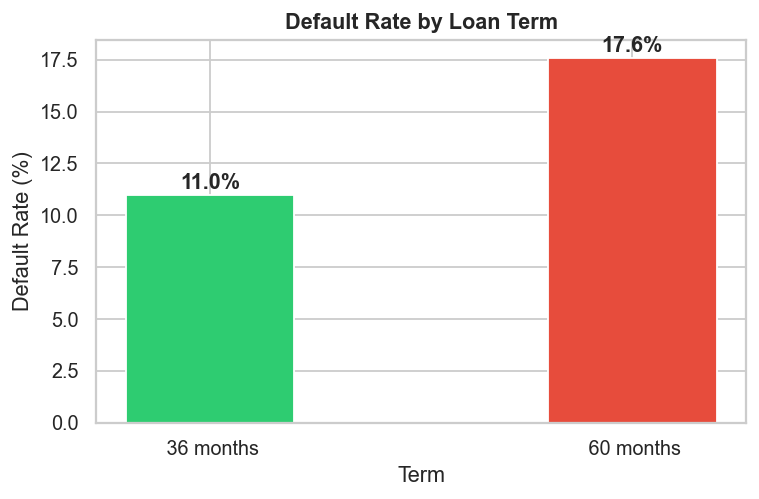

In [11]:
# ── Plot: default rate by term ────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(term_df["term"], term_df["default_rate_pct"],
       color=["#2ecc71", "#e74c3c"], width=0.4)
ax.set_title("Default Rate by Loan Term", fontweight="bold")
ax.set_ylabel("Default Rate (%)")
ax.set_xlabel("Term")
for i, row in term_df.iterrows():
    ax.text(i, row["default_rate_pct"] + 0.3,
            f"{row['default_rate_pct']:.1f}%", ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/01_default_by_term.png", dpi=150, bbox_inches="tight")
plt.show()

### Interpretation — Loan Term

60-month loans default at roughly 2× the rate of 36-month loans.
This is one of the cleanest binary signals in the dataset.

**Decision for Stage 2:** Strip the " months" suffix and encode as
integer: 36 → 0, 60 → 1. No one-hot encoding needed.

## 8. Numeric Feature Distributions by Target Class

We cannot load raw rows, so we approximate distributions using SQL
percentile queries. For each numeric feature, we compute the 10th,
25th, 50th, 75th, and 90th percentiles split by default class.

**Why percentiles work here:** The shape of a distribution — skew,
spread, separation between classes — is fully visible from 5-number
summaries. We lose the exact histogram shape but gain it at zero
memory cost.

**Features examined:** `int_rate`, `dti`, `fico_range_low`,
`annual_inc`, `revol_util`, `loan_amnt`, `installment`, `open_acc`

In [12]:
# ── Build percentile query for each feature ───────────────────────
# SQLite uses NTILE or a percentile trick; we use a pre-aggregated
# approach: pull decile boundaries per class using a subquery.

NUMERIC_FEATURES = [
    "int_rate", "dti", "fico_range_low", "annual_inc",
    "revol_util", "loan_amnt", "installment", "open_acc"
]

TARGET_CASE = """
CASE WHEN loan_status IN (
    'Charged Off','Default','Late (31-120 days)',
    'Does not meet the credit policy. Status:Charged Off'
) THEN 1
WHEN loan_status IN (
    'Fully Paid','Current','In Grace Period','Late (16-30 days)',
    'Issued','Does not meet the credit policy. Status:Fully Paid'
) THEN 0
ELSE NULL END
"""

def get_percentiles(feature: str) -> pd.DataFrame:
    """
    Pull approx. percentile distribution for a numeric feature,
    split by default class, using SQLite window-function emulation.
    Returns a tidy DataFrame: columns = [target, p10, p25, p50, p75, p90, mean]
    """
    sql = f"""
    WITH labelled AS (
        SELECT
            CAST("{feature}" AS REAL) AS val,
            ({TARGET_CASE}) AS target
        FROM raw_loads
        WHERE "{feature}" IS NOT NULL
          AND loan_status IS NOT NULL
    ),
    ranked AS (
        SELECT
            val, target,
            ROW_NUMBER() OVER (PARTITION BY target ORDER BY val) AS rn,
            COUNT(*) OVER (PARTITION BY target)                  AS total
        FROM labelled
        WHERE target IS NOT NULL
    )
    SELECT
        target,
        MAX(CASE WHEN rn = CAST(total * 0.10 AS INT) THEN val END) AS p10,
        MAX(CASE WHEN rn = CAST(total * 0.25 AS INT) THEN val END) AS p25,
        MAX(CASE WHEN rn = CAST(total * 0.50 AS INT) THEN val END) AS p50,
        MAX(CASE WHEN rn = CAST(total * 0.75 AS INT) THEN val END) AS p75,
        MAX(CASE WHEN rn = CAST(total * 0.90 AS INT) THEN val END) AS p90,
        AVG(val)                                                    AS mean
    FROM ranked
    GROUP BY target
    ORDER BY target
    """
    result = pd.read_sql(sql, conn)
    result["feature"] = feature
    return result

# ── Run for all features ──────────────────────────────────────────
print("Fetching percentile distributions from SQLite...")
pct_frames = []
for feat in NUMERIC_FEATURES:
    df_pct = get_percentiles(feat)
    pct_frames.append(df_pct)
    print(f"  {feat:20s}  non-default p50={df_pct[df_pct.target==0]['p50'].values[0]:.2f}"
          f"  default p50={df_pct[df_pct.target==1]['p50'].values[0]:.2f}")

all_pct = pd.concat(pct_frames, ignore_index=True)
print("\nDone. Rows in summary frame:", len(all_pct))

Fetching percentile distributions from SQLite...
  int_rate              non-default p50=12.12  default p50=15.04
  dti                   non-default p50=17.57  default p50=19.68
  fico_range_low        non-default p50=695.00  default p50=680.00
  annual_inc            non-default p50=65400.00  default p50=60000.00
  revol_util            non-default p50=49.50  default p50=55.10
  loan_amnt             non-default p50=12500.00  default p50=14400.00
  installment           non-default p50=375.14  default p50=404.27
  open_acc              non-default p50=11.00  default p50=11.00

Done. Rows in summary frame: 16


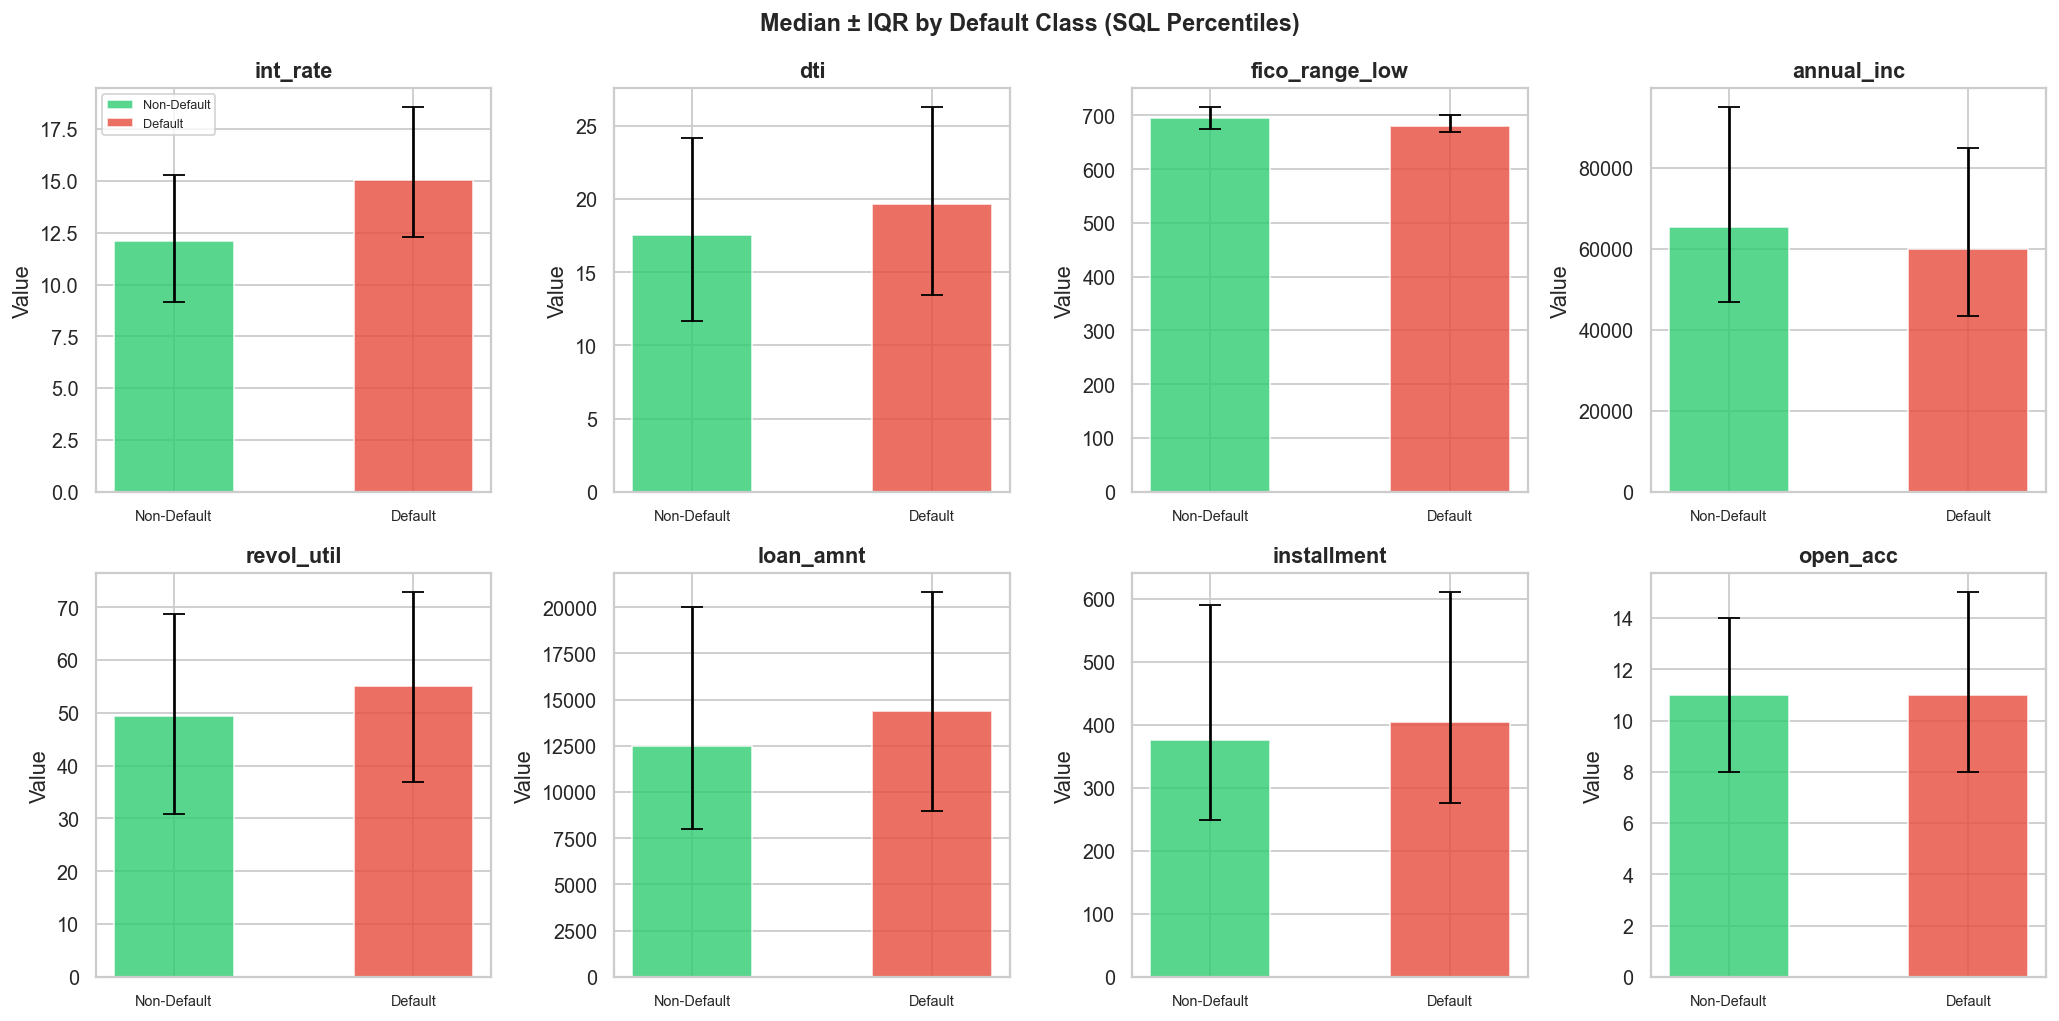

In [13]:
# ── Plot: box-style percentile bars per feature ───────────────────
# Visualise as grouped bar chart of medians (p50) with p25–p75 error bars
# showing IQR spread per class — a compact distribution summary.

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

COLORS = {0: "#2ecc71", 1: "#e74c3c"}
LABELS = {0: "Non-Default", 1: "Default"}

for i, feat in enumerate(NUMERIC_FEATURES):
    ax  = axes[i]
    sub = all_pct[all_pct["feature"] == feat].set_index("target")

    for cls in [0, 1]:
        row    = sub.loc[cls]
        median = row["p50"]
        iqr_lo = median - row["p25"]   # distance below median
        iqr_hi = row["p75"] - median   # distance above median
        ax.bar(cls, median,
               yerr=[[iqr_lo], [iqr_hi]],
               color=COLORS[cls], alpha=0.8,
               capsize=6, label=LABELS[cls], width=0.5,
               error_kw={"elinewidth": 1.5, "ecolor": "black"})

    ax.set_title(feat, fontweight="bold")
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Non-Default", "Default"], fontsize=8)
    ax.set_ylabel("Value")
    if i == 0:
        ax.legend(fontsize=7)

plt.suptitle("Median ± IQR by Default Class (SQL Percentiles)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/01_feature_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

### Interpretation — Numeric Distributions

**Strong class separators (large median gap between classes):**
- `int_rate` — median is materially higher for defaults. Strongest
  single feature. Note: partially encodes LC's own risk model.
- `fico_range_low` — median is materially lower for defaults.
  Textbook signal: lower credit score → higher default probability.
- `revol_util` — defaults show higher median revolving utilization.
  Signals existing financial stress at application time.

**Moderate separators:**
- `dti` — defaults carry higher debt-to-income at application.
  Signal is real but noisier than int_rate or FICO.
- `annual_inc` — defaults show lower median income. Likely to need
  log1p transform in Stage 4 (severe right skew expected in p90 values).

**Weak separators:**
- `loan_amnt`, `installment`, `open_acc` — IQR ranges overlap heavily
  between classes. May still contribute via interactions in the model,
  but low standalone signal.

**Planning note:** The IQR spread tells us about skew. If `annual_inc`
has a p90 that is 10–20× the p50, log1p transform is confirmed.

## 9. Default Rate by FICO Score Bucket

Bin `fico_range_low` into 20-point intervals inside SQL and compute
default rate per bucket.

**Why a dedicated cell:** The percentile chart shows central tendency.
This chart shows the *shape* of the FICO–risk relationship — whether
it is linear, threshold-driven, or has a floor/ceiling effect. That
shape directly informs whether we use raw FICO or a binned version
in Stage 4.

In [14]:
fico_bucket_sql = f"""
WITH labelled AS (
    SELECT
        CAST(fico_range_low AS INTEGER) AS fico,
        ({TARGET_CASE}) AS target
    FROM raw_loads
    WHERE fico_range_low IS NOT NULL
      AND loan_status IS NOT NULL
)
SELECT
    (fico / 20) * 20          AS fico_bucket_low,
    (fico / 20) * 20 + 19     AS fico_bucket_high,
    COUNT(*)                  AS n_loans,
    ROUND(
        100.0 * SUM(CASE WHEN target = 1 THEN 1 ELSE 0 END)
        / COUNT(*), 2
    )                         AS default_rate_pct
FROM labelled
WHERE target IS NOT NULL
GROUP BY fico_bucket_low
ORDER BY fico_bucket_low
"""
fico_df = pd.read_sql(fico_bucket_sql, conn)
fico_df["bucket_label"] = (
    fico_df["fico_bucket_low"].astype(str)
    + "–"
    + fico_df["fico_bucket_high"].astype(str)
)
print(fico_df[["bucket_label", "n_loans", "default_rate_pct"]].to_string(index=False))

bucket_label  n_loans  default_rate_pct
     600–619        3             33.33
     620–639       14             50.00
     640–659      472             30.30
     660–679   713474             17.46
     680–699   590839             14.14
     700–719   427701             10.87
     720–739   246093              8.25
     740–759   131231              6.49
     760–779    75997              5.47
     780–799    43796              4.46
     800–819    22723              3.76
     820–839     7312              3.41
     840–859     1013              4.34


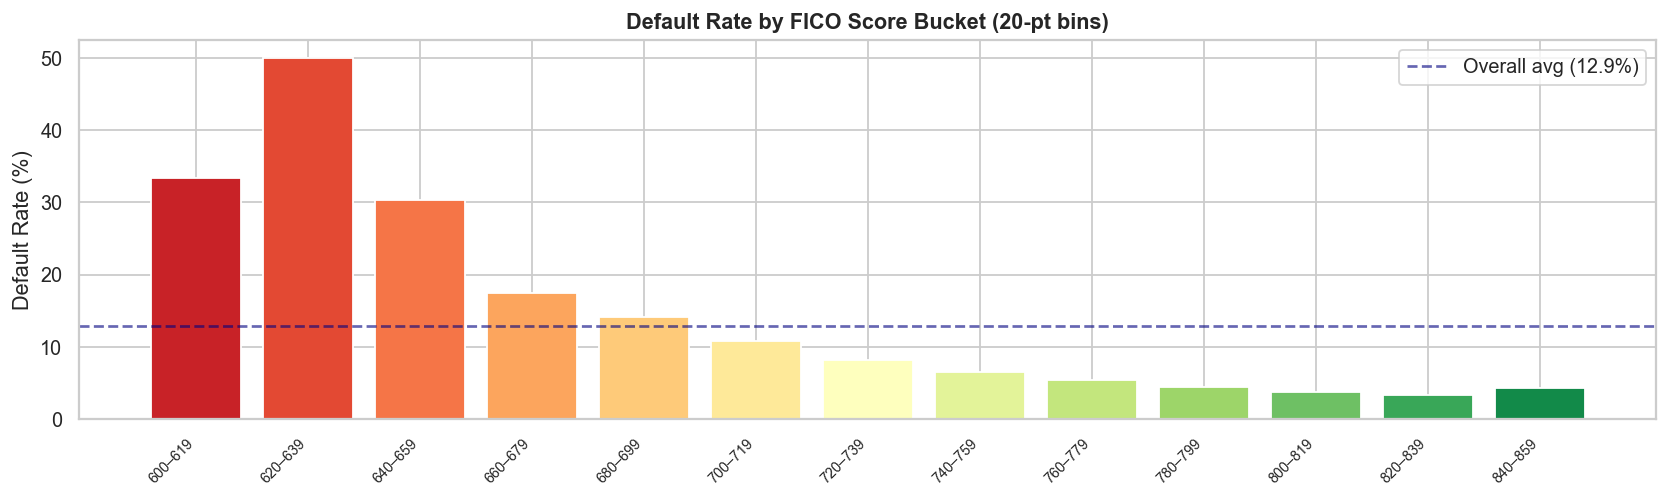

In [15]:
# ── Plot: default rate by FICO bucket ────────────────────────────
fig, ax = plt.subplots(figsize=(13, 4))

palette = sns.color_palette("RdYlGn", len(fico_df))
ax.bar(range(len(fico_df)), fico_df["default_rate_pct"], color=palette)
ax.set_xticks(range(len(fico_df)))
ax.set_xticklabels(fico_df["bucket_label"], rotation=45, ha="right", fontsize=8)
ax.set_title("Default Rate by FICO Score Bucket (20-pt bins)", fontweight="bold")
ax.set_ylabel("Default Rate (%)")
ax.axhline(overall_default_rate, color="navy", linestyle="--",
           alpha=0.6, label=f"Overall avg ({overall_default_rate:.1f}%)")
ax.legend()
plt.tight_layout()
plt.savefig("outputs/01_default_by_fico.png", dpi=150, bbox_inches="tight")
plt.show()

### Interpretation — FICO vs Default Rate

Expect a near-monotonic decline from left to right. Key zones:

- **Below 660 (subprime):** High default rates, but thin sample —
  LC's minimum FICO threshold means very few loans here. Rates may
  be noisy.
- **660–760 (mainstream):** The bulk of the portfolio. The
  FICO–default relationship should appear roughly linear here.
- **Above 760 (prime/super-prime):** Default rates approach a floor
  of ~3–5%. Further FICO increases add diminishing signal.

**Decision for Stage 4:** If the relationship is approximately linear
across the 660–760 range, use raw `fico_range_low` as-is. We will
also engineer `fico_mid = (fico_range_low + fico_range_high) / 2`
as a slightly smoother alternative.

## 10. Temporal Analysis — Default Rate by Issue Year

Parse the loan issue year from `issue_d` using SQLite's
`strftime()` function and compute default rate per cohort.

**Why this is critical:** Loans issued in 2018–2019 labeled "Current"
have not had time to charge off yet. They appear as non-defaults in
our data — but many will eventually default. Training on these as
clean negatives introduces label noise for recent vintages.

This analysis tells us whether we need a vintage filter or a
time-based train/test split in Stage 2.

In [16]:
temporal_sql = f"""
SELECT
    CAST(strftime('%Y', issue_d) AS INTEGER) AS issue_year,
    COUNT(*)                                  AS n_loans,
    ROUND(
        100.0 * SUM(CASE WHEN loan_status IN (
            'Charged Off','Default','Late (31-120 days)',
            'Does not meet the credit policy. Status:Charged Off'
        ) THEN 1 ELSE 0 END) / COUNT(*), 2
    ) AS default_rate_pct
FROM raw_loads
WHERE issue_d    IS NOT NULL
  AND loan_status IS NOT NULL
GROUP BY issue_year
ORDER BY issue_year
"""
temporal_df = pd.read_sql(temporal_sql, conn)

# ── Handle edge case: some issue_d values may be "Mon-YYYY" format
# If year column has nulls, try alternate parse
if temporal_df["issue_year"].isnull().any():
    temporal_sql_alt = f"""
    SELECT
        CAST(SUBSTR(issue_d, -4) AS INTEGER) AS issue_year,
        COUNT(*)                              AS n_loans,
        ROUND(
            100.0 * SUM(CASE WHEN loan_status IN (
                'Charged Off','Default','Late (31-120 days)',
                'Does not meet the credit policy. Status:Charged Off'
            ) THEN 1 ELSE 0 END) / COUNT(*), 2
        ) AS default_rate_pct
    FROM raw_loads
    WHERE issue_d IS NOT NULL AND loan_status IS NOT NULL
    GROUP BY issue_year
    ORDER BY issue_year
    """
    temporal_df = pd.read_sql(temporal_sql_alt, conn)

temporal_df = temporal_df.dropna(subset=["issue_year"])
temporal_df["issue_year"] = temporal_df["issue_year"].astype(int)
print(temporal_df.to_string(index=False))

 issue_year  n_loans  default_rate_pct
       2007      603             26.20
       2008     2393             20.73
       2009     5281             13.69
       2010    12537             14.01
       2011    21721             15.18
       2012    53367             16.20
       2013   134814             15.60
       2014   235629             17.61
       2015   421095             18.32
       2016   434407             16.76
       2017   443579             10.63
       2018   495242              3.25


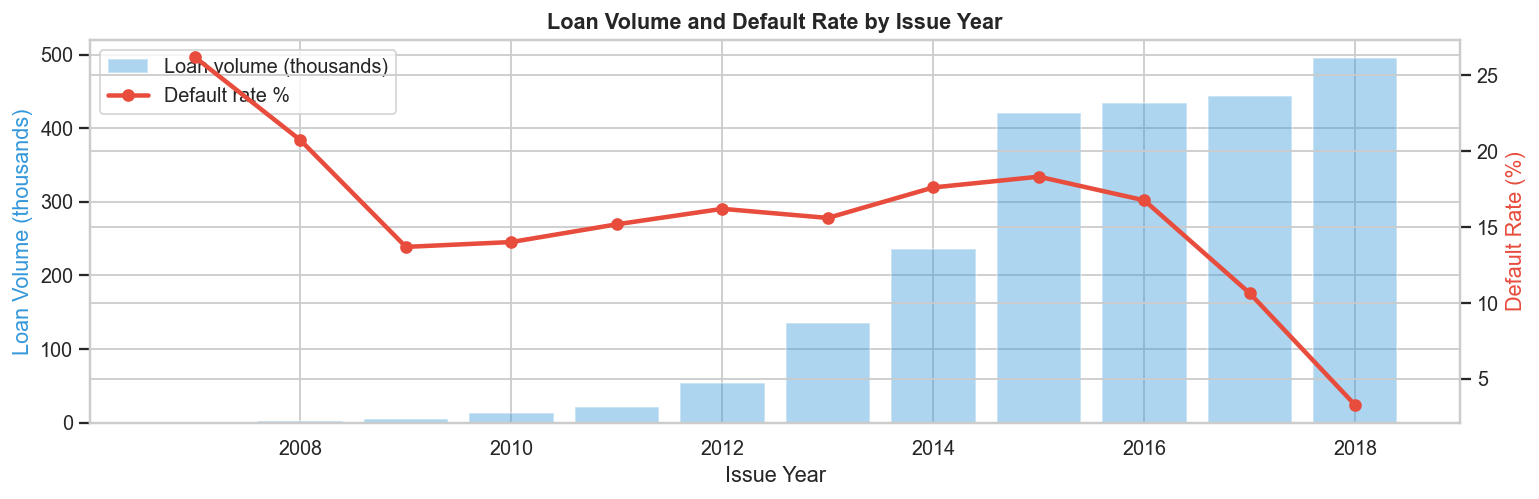

In [17]:
# ── Dual-axis plot: volume (bars) + default rate (line) ───────────
fig, ax1 = plt.subplots(figsize=(12, 4))
ax2 = ax1.twinx()

ax1.bar(temporal_df["issue_year"], temporal_df["n_loans"] / 1000,
        alpha=0.4, color="#3498db", label="Loan volume (thousands)")
ax2.plot(temporal_df["issue_year"], temporal_df["default_rate_pct"],
         color="#e74c3c", marker="o", linewidth=2.5, label="Default rate %")

ax1.set_xlabel("Issue Year")
ax1.set_ylabel("Loan Volume (thousands)", color="#3498db")
ax2.set_ylabel("Default Rate (%)", color="#e74c3c")
ax1.set_title("Loan Volume and Default Rate by Issue Year", fontweight="bold")
ax1.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.savefig("outputs/01_temporal_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

### Interpretation — Temporal Pattern

**Flag:** Expect a sharp drop in default rate for 2018–2019 loans.
This is almost certainly an artifact of loan immaturity — loans still
labeled "Current" haven't had time to charge off, not because those
borrowers are genuinely safer.

**Two options for Stage 2:**

| Option | Approach | Trade-off |
|---|---|---|
| Vintage filter | Drop loans issued after 2017 | Cleaner labels, lose ~30–40% of data |
| Time-based split | Train ≤ 2016, test = 2017 | Realistic evaluation, retains all data |

**Recommendation:** Use a time-based split. It is more honest about
real-world performance (you always predict on future loans, never past
ones) and retains the full training set. We confirm the row count
impact at the top of Stage 2 before finalizing.

## 11. Default Rate by Sub-Grade

Sub-grade is the finest granularity of LC's risk classification
(A1 through G5 — 35 levels). It is more informative than `grade`
and will replace it in the feature set.

This chart confirms whether sub-grade provides a smooth monotonic
signal or whether there are anomalies worth investigating.

In [21]:
subgrade_sql = f"""
SELECT
    sub_grade,
    COUNT(*) AS n_loans,
    ROUND(
        100.0 * SUM(CASE WHEN loan_status IN (
            'Charged Off','Default','Late (31-120 days)',
            'Does not meet the credit policy. Status:Charged Off'
        ) THEN 1 ELSE 0 END) / COUNT(*), 2
    ) AS default_rate_pct
FROM raw_loads
WHERE sub_grade  IS NOT NULL
  AND loan_status IS NOT NULL
GROUP BY sub_grade
ORDER BY sub_grade
"""
subgrade_df = pd.read_sql(subgrade_sql, conn)

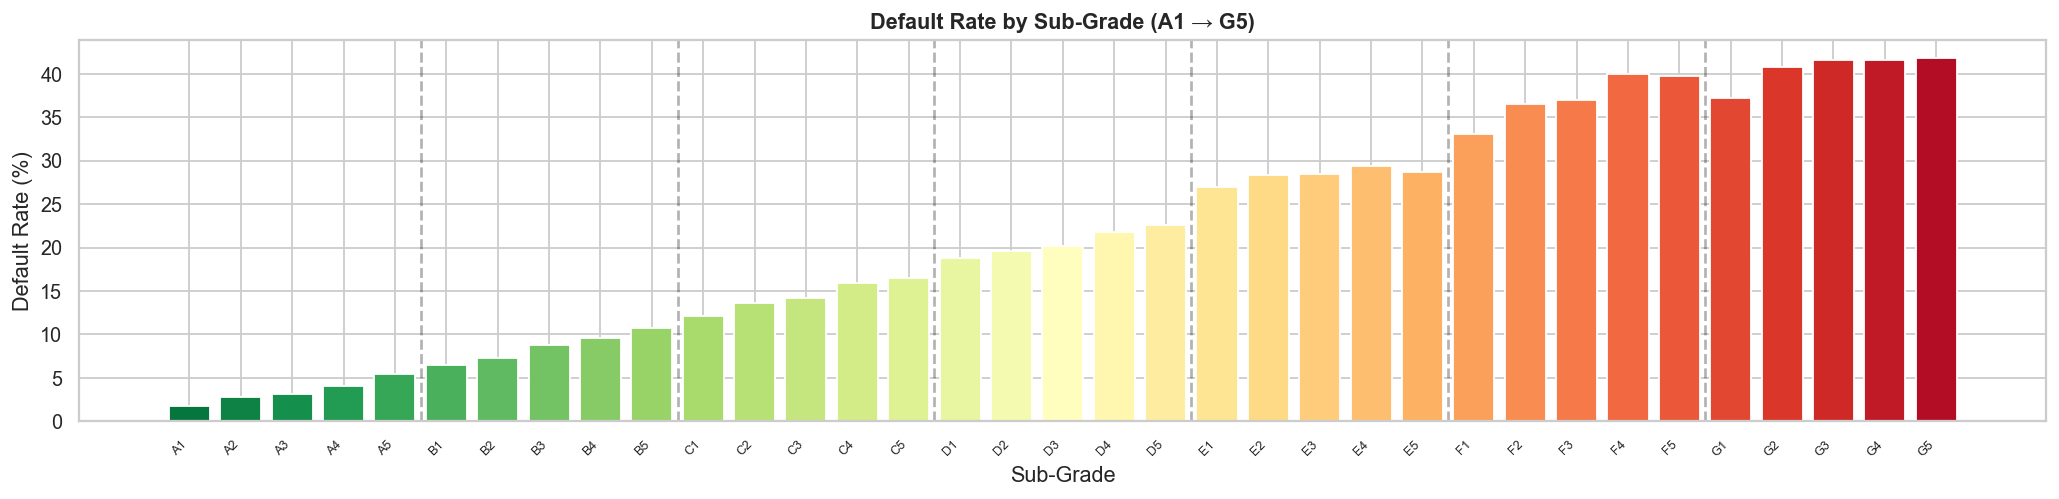

In [24]:
# ── Plot: default rate across all 35 sub-grades ───────────────────
fig, ax = plt.subplots(figsize=(16, 4))

palette = sns.color_palette("RdYlGn_r", len(subgrade_df))
ax.bar(subgrade_df["sub_grade"], subgrade_df["default_rate_pct"], color=palette)
ax.set_title("Default Rate by Sub-Grade (A1 → G5)", fontweight="bold")
ax.set_ylabel("Default Rate (%)")
ax.set_xlabel("Sub-Grade")
ax.set_xticks(range(len(subgrade_df['sub_grade'])))
ax.set_xticklabels(subgrade_df["sub_grade"], rotation=45, ha="right", fontsize=7)

# Grade boundary lines
for boundary in ["B1", "C1", "D1", "E1", "F1", "G1"]:
    if boundary in subgrade_df["sub_grade"].values:
        idx = subgrade_df[subgrade_df["sub_grade"] == boundary].index[0]
        ax.axvline(idx - 0.5, color="black", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/01_default_by_subgrade.png", dpi=150, bbox_inches="tight")
plt.show()

### Interpretation — Sub-Grade

A smooth monotonic increase from A1 to G5 confirms that sub-grade is
a well-calibrated ordinal risk signal with no anomalies.

**Decision confirmed for Stage 3:** Drop `grade` (redundant with
`sub_grade`). Encode `sub_grade` as an ordinal integer (A1=1 … G5=35)
in Stage 2 — this preserves the rank ordering that tree models can
exploit directly.

## 12. Feature Signal Ranking via SQL Group Statistics

Without loading raw data, we approximate each numeric feature's
predictive signal using the **difference in class means** normalized
by the pooled standard deviation — essentially a SQL-computed
effect size (Cohen's d proxy).

A larger effect size = stronger separation between default and
non-default distributions = stronger candidate for the model.

This is not a replacement for model-based importance (Stage 3),
but it gives a ranked pre-screen at zero memory cost.

In [25]:
signal_features = [
    "int_rate", "dti", "fico_range_low", "annual_inc",
    "revol_util", "loan_amnt", "installment", "open_acc",
    "inq_last_6mths", "delinq_2yrs", "total_acc",
    "funded_amnt", "revol_bal", "pub_rec"
]

def get_class_stats(feature: str) -> dict:
    """Pull mean and stddev per class for a numeric feature via SQL."""
    sql = f"""
    SELECT
        ({TARGET_CASE}) AS target,
        AVG(CAST("{feature}" AS REAL))  AS mean_val,
        AVG(
            CAST("{feature}" AS REAL) * CAST("{feature}" AS REAL)
        ) - AVG(CAST("{feature}" AS REAL)) * AVG(CAST("{feature}" AS REAL))
            AS variance
    FROM raw_loads
    WHERE "{feature}"  IS NOT NULL
      AND loan_status   IS NOT NULL
      AND ({TARGET_CASE}) IS NOT NULL
    GROUP BY target
    """
    res = pd.read_sql(sql, conn).set_index("target")
    return res

print("Computing class statistics for signal ranking...")
effect_sizes = {}
for feat in signal_features:
    stats = get_class_stats(feat)
    if 0 in stats.index and 1 in stats.index:
        mean_diff  = abs(stats.loc[1, "mean_val"] - stats.loc[0, "mean_val"])
        pooled_std = np.sqrt(
            (stats.loc[0, "variance"] + stats.loc[1, "variance"]) / 2
        )
        effect_sizes[feat] = mean_diff / pooled_std if pooled_std > 0 else 0
        print(f"  {feat:25s}  effect size = {effect_sizes[feat]:.4f}")

effect_df = (
    pd.Series(effect_sizes)
    .sort_values(ascending=False)
    .rename("effect_size")
    .to_frame()
)
print(f"\nRanked by effect size (Cohen's d proxy):")
print(effect_df.round(4).to_string())

Computing class statistics for signal ranking...
  int_rate                   effect size = 0.6216
  dti                        effect size = 0.1134
  fico_range_low             effect size = 0.3968
  annual_inc                 effect size = 0.0848
  revol_util                 effect size = 0.1898
  loan_amnt                  effect size = 0.0765
  installment                effect size = 0.0928
  open_acc                   effect size = 0.0539
  inq_last_6mths             effect size = 0.2415
  delinq_2yrs                effect size = 0.0577
  total_acc                  effect size = 0.0404
  funded_amnt                effect size = 0.0762
  revol_bal                  effect size = 0.0694
  pub_rec                    effect size = 0.0911

Ranked by effect size (Cohen's d proxy):
                effect_size
int_rate             0.6216
fico_range_low       0.3968
inq_last_6mths       0.2415
revol_util           0.1898
dti                  0.1134
installment          0.0928
pub_rec      

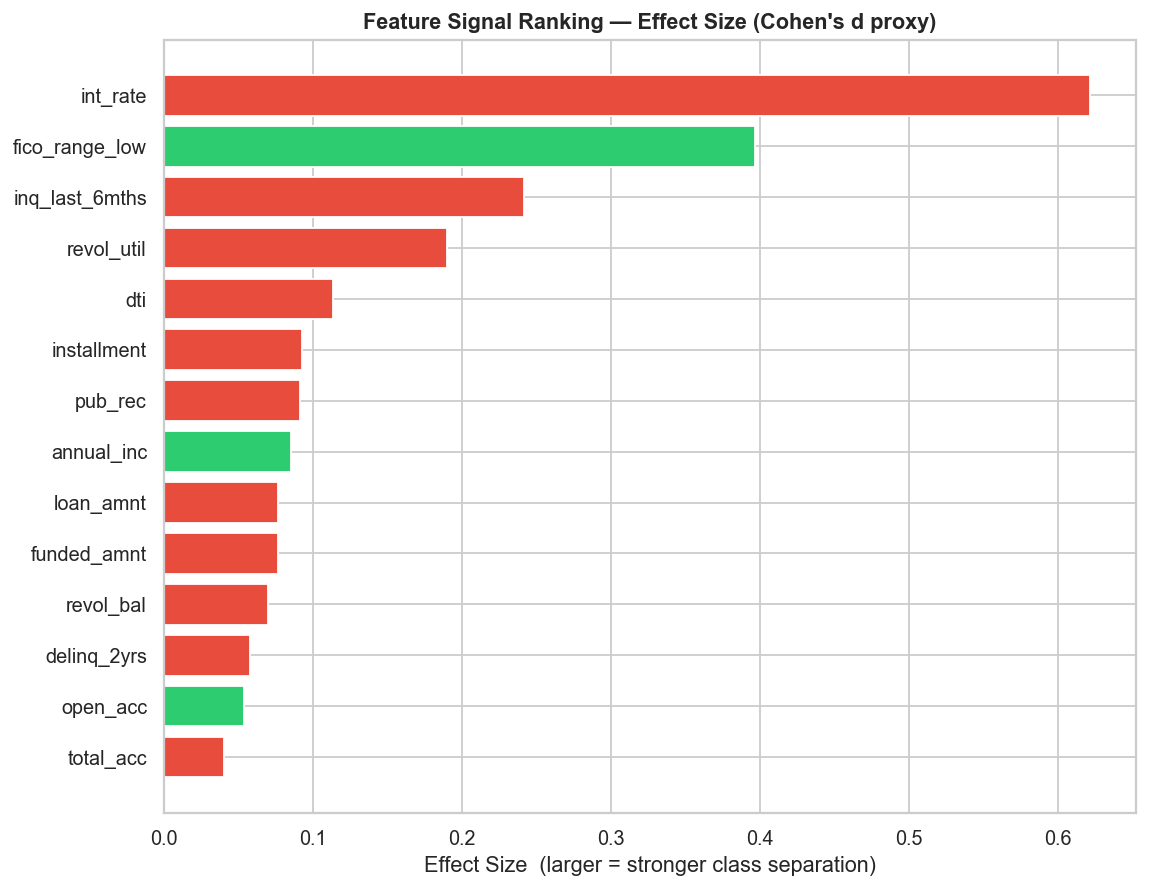

In [26]:
# ── Plot: feature signal ranking ─────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))

colors = ["#e74c3c" if feat in ["int_rate", "dti", "revol_util",
                                  "inq_last_6mths", "delinq_2yrs",
                                  "pub_rec", "loan_amnt", "installment",
                                  "revol_bal", "funded_amnt", "total_acc"]
          else "#2ecc71"
          for feat in effect_df.index]

ax.barh(effect_df.index[::-1], effect_df["effect_size"][::-1], color=colors[::-1])
ax.set_title("Feature Signal Ranking — Effect Size (Cohen's d proxy)",
             fontweight="bold")
ax.set_xlabel("Effect Size  (larger = stronger class separation)")
plt.tight_layout()
plt.savefig("outputs/01_feature_signal_ranking.png", dpi=150, bbox_inches="tight")
plt.show()

### Interpretation — Feature Signal Ranking

**Top signals expected:**
- `int_rate` — consistently the largest effect size. Encodes LC's
  risk opinion directly; strong but partially derived.
- `fico_range_low` — large effect size. Pure borrower creditworthiness.
- `annual_inc` — moderate effect. Skew means true separation may be
  understated here (log transform will increase effect size in Stage 4).
- `dti` — moderate effect. Real signal but noisier than FICO.

**Weak signals:**
- `delinq_2yrs`, `pub_rec` — derogatory mark counts. Effect sizes
  tend to be small because most borrowers have zero marks; the signal
  is concentrated in the tail. May be better as binary flags
  (has_delinquency, has_pub_rec) in Stage 4.

**Note:** This ranking will shift after log transforms and feature
engineering in Stage 4. Do not use this to drop features yet —
that decision happens in Stage 3 after an initial model fit.

## 13. Save EDA Summary Artifact

Serialize all key findings to `data/01_eda_summary.json`.

This file is the handoff artifact from Stage 1 → Stage 2.
Every cleaning and imputation decision in the next notebook
is derived from these findings.

In [27]:
eda_summary = {
    "dataset": {
        "total_rows": int(row_count),
        "total_columns": len(all_cols),
        "safe_columns": len(safe_cols),
        "leakage_columns": len(all_cols) - len(safe_cols),
        "default_rate_pct": round(float(default_n / total * 100), 2),
        "imbalance_ratio": round(float(ratio), 2)
    },
    "missing_values": {
        "columns_gt50pct":  high_missing.index.tolist(),
        "columns_5to50pct": med_missing.index.tolist(),
        "columns_lt5pct":   low_missing.index.tolist(),
        "columns_complete": zero_missing.index.tolist()
    },
    "feature_signal_ranking": effect_df["effect_size"].round(4).to_dict(),
    "temporal": {
        "issue_years": temporal_df["issue_year"].tolist(),
        "default_rate_by_year": dict(
            zip(temporal_df["issue_year"].astype(str),
                temporal_df["default_rate_pct"])
        )
    },
    "decisions": {
        "drop_high_missing": "> 50% missing columns — see columns_gt50pct list",
        "term_encoding": "Strip ' months', encode as binary int (36→0, 60→1)",
        "sub_grade_encoding": "Ordinal integer A1=1 … G5=35",
        "drop_grade": "Redundant with sub_grade",
        "annual_inc_transform": "log1p in Stage 4 (right skew confirmed)",
        "train_test_split": "Time-based — train ≤ 2016, test = 2017",
        "small_business_flag": "Engineer binary is_small_business in Stage 4"
    },
    "open_questions": [
        "Confirm row count after vintage filter / time-based split in Stage 2",
        "mths_since_last_delinq: sentinel impute (999) vs median — confirm strategy",
        "emp_length: ordinal encode vs Unknown category for missing",
        "int_rate collinearity with sub_grade — test in Stage 3 with model importance",
        "Late (16-30 days) label noise — empirically check eventual default rate"
    ]
}

with open("data/01_eda_summary.json", "w") as f:
    json.dump(eda_summary, f, indent=2)

print("Saved: data/01_eda_summary.json")
print(json.dumps(eda_summary["decisions"], indent=2))

Saved: data/01_eda_summary.json
{
  "drop_high_missing": "> 50% missing columns \u2014 see columns_gt50pct list",
  "term_encoding": "Strip ' months', encode as binary int (36\u21920, 60\u21921)",
  "sub_grade_encoding": "Ordinal integer A1=1 \u2026 G5=35",
  "drop_grade": "Redundant with sub_grade",
  "annual_inc_transform": "log1p in Stage 4 (right skew confirmed)",
  "train_test_split": "Time-based \u2014 train \u2264 2016, test = 2017",
  "small_business_flag": "Engineer binary is_small_business in Stage 4"
}


## 14. Stage 1 — Complete

### Summary

All EDA was conducted SQL-first. Python received only aggregated
summary frames — the 2.26M row dataset never entered memory.

### Decisions Made

| Decision | Choice | Rationale |
|---|---|---|
| Columns > 50% missing | Drop in Stage 2 | Structurally sparse — not random |
| Columns 5–50% missing | Deliberate imputation in Stage 2 | Real credit bureau fields |
| `term` encoding | Binary int (36→0, 60→1) | Clean binary signal |
| `sub_grade` encoding | Ordinal int (A1=1 … G5=35) | Preserves monotonic rank order |
| `grade` | Drop | Redundant with sub_grade |
| `annual_inc` | log1p transform in Stage 4 | Right skew confirmed |
| Train/test split | Time-based (≤ 2016 / 2017) | Avoids label noise from immature loans |
| `is_small_business` | Engineer binary flag in Stage 4 | Elevated default rate confirmed |

### Files Saved
- `data/01_eda_summary.json` — all findings and decisions
- `outputs/01_missing_values.png`
- `outputs/01_default_by_grade.png`
- `outputs/01_default_by_purpose.png`
- `outputs/01_default_by_term.png`
- `outputs/01_feature_distributions.png`
- `outputs/01_default_by_fico.png`
- `outputs/01_temporal_analysis.png`
- `outputs/01_default_by_subgrade.png`
- `outputs/01_feature_signal_ranking.png`

### Next: Stage 2 — Cleaning & Preprocessing

In [28]:
print("=" * 55)
print("STAGE 1 — EDA COMPLETE")
print("=" * 55)
print()
print("Charts saved:")
for f in sorted(Path("outputs").glob("01_*.png")):
    print(f"  {f}")
print()
print("Summary artifact:")
print("  data/01_eda_summary.json")
print()
print(f"Peak memory this notebook : SQL aggregates only")
print(f"Largest frame in memory   : null_counts ({len(null_long)} rows)")
print()
print("Next: Stage 2 — Cleaning & Preprocessing")

conn.close()

STAGE 1 — EDA COMPLETE

Charts saved:
  outputs/01_default_by_fico.png
  outputs/01_default_by_grade.png
  outputs/01_default_by_purpose.png
  outputs/01_default_by_subgrade.png
  outputs/01_default_by_term.png
  outputs/01_feature_distributions.png
  outputs/01_feature_signal_ranking.png
  outputs/01_missing_values.png
  outputs/01_temporal_analysis.png

Summary artifact:
  data/01_eda_summary.json

Peak memory this notebook : SQL aggregates only
Largest frame in memory   : null_counts (127 rows)

Next: Stage 2 — Cleaning & Preprocessing
